# Introduction
### World Happiness Report Analysis (2015–2019)
This project analyzes the World Happiness Report dataset from 2015 to 2019. The goal is to understand which factors influence happiness across countries.  
These features represent different social, economic, and psychological factors that may influence happiness:   
Happiness Score: overall life evaluation score based on survey responses (0.0 to 10.0). This is target variable  
GDP per Capita: measures the average economic output per person, indicating the wealth of a country  
Social Support: the perceived support from friends, family, or government  
Healthy Life Expectancy: the average number of years a person is expected to live in good healthy. Life expectancy based on WHO health metrics  
Freedom to Make Life Choices: the degree of autonomy citizens feel they have. Measures how free individuals feel to make their own choices in life  
Generosity: a measure based on recent charitable donations. Reflects how willing people are to donate or help others  
Perceptions of Corruption: citizens' trust in their government and institutions. Indicates how much people believe corruption exists in their country  

### Questions / Hypotheses
- Are richer countries always happier?
- Do non-material factors have a stronger impact than economic factors?
- Which features are most important in predicting happiness?  
- We hypothesize that non-material factors such as social support and health have a stronger impact than economic factors.

# 1. Exploratory Data Analysis
This section explores the structure, distribution, and relationships in the dataset.

In [1]:
# Import Librares
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#See data paths
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/haidangln/world-happiness-edited/2015-edited.csv
/kaggle/input/datasets/haidangln/world-happiness-edited/2018-edited.csv
/kaggle/input/datasets/haidangln/world-happiness-edited/2019-edited.csv
/kaggle/input/datasets/haidangln/world-happiness-edited/2017-edited.csv
/kaggle/input/datasets/haidangln/world-happiness-edited/2016-edited.csv


In [2]:
# load data
df15 = pd.read_csv("/kaggle/input/datasets/haidangln/world-happiness-edited/2015-edited.csv")
df16 = pd.read_csv("/kaggle/input/datasets/haidangln/world-happiness-edited/2015-edited.csv")
df17 = pd.read_csv("/kaggle/input/datasets/haidangln/world-happiness-edited/2015-edited.csv")
df18 = pd.read_csv("/kaggle/input/datasets/haidangln/world-happiness-edited/2015-edited.csv")
df19 = pd.read_csv("/kaggle/input/datasets/haidangln/world-happiness-edited/2015-edited.csv")

# Add year column
df15["Year"] = 2015
df16["Year"] = 2016
df17["Year"] = 2017
df18["Year"] = 2018
df19["Year"] = 2019

# Combine data
df = pd.concat([df15, df16, df17, df18, df19], ignore_index=True)

# Dataset Overview
df.info()
df.head()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 790 entries, 0 to 789
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  790 non-null    int64  
 1   Country or region             790 non-null    object 
 2   Score                         790 non-null    float64
 3   GDP per capita                790 non-null    float64
 4   Social support                790 non-null    float64
 5   Healthy life expectancy       790 non-null    float64
 6   Freedom to make life choices  790 non-null    float64
 7   Generosity                    790 non-null    float64
 8   Perceptions of corruption     790 non-null    float64
 9   Year                          790 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 61.8+ KB


,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Year
count,790.000000,790.000000,790.000000,790.000000,790.000000,790.000000,790.000000,790.000000,790.000000
mean,79.493671,5.375734,0.846137,0.991046,0.630259,0.428615,0.237296,0.143422,2017.000000
std,45.638235,1.142104,0.402098,0.271678,0.246451,0.150310,0.126363,0.119729,1.415109
min,1.000000,2.839000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2015.000000
25%,40.000000,4.518000,0.545580,0.855630,0.438730,0.328180,0.149820,0.061460,2016.000000
50%,79.500000,5.232500,0.910245,1.029510,0.696705,0.435515,0.216130,0.107220,2017.000000
75%,119.000000,6.269000,1.159910,1.216240,0.811600,0.550110,0.311050,0.180600,2018.000000
max,158.000000,7.587000,1.690420,1.402230,1.025250,0.669730,0.795880,0.551910,2019.000000


## 1.1 Distribution of Happiness Score
This section visualizes the distribution of the happiness score to understand its overall pattern and spread.

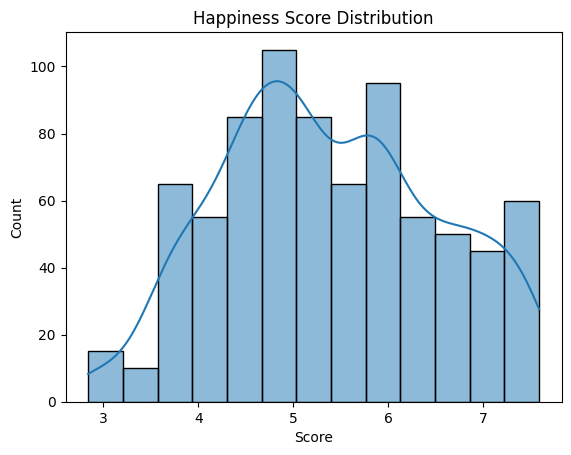

In [3]:
# Histogram
sns.histplot(df['Score'], kde=True)
plt.title("Happiness Score Distribution")
plt.show()

The histogram shows that most countries have a happiness score between 4.5 and 6.5, indicating a generally moderate level of happiness worldwide.

There are fewer countries with extremely low or high happiness scores, suggesting that extreme values are relatively rare.

The distribution appears roughly normal, which is beneficial for many machine learning models.

## 1.2 Features Impact on Happiness Score
This section visualizes the relationship between key features and the happiness score using scatter plots to identify important predictors.

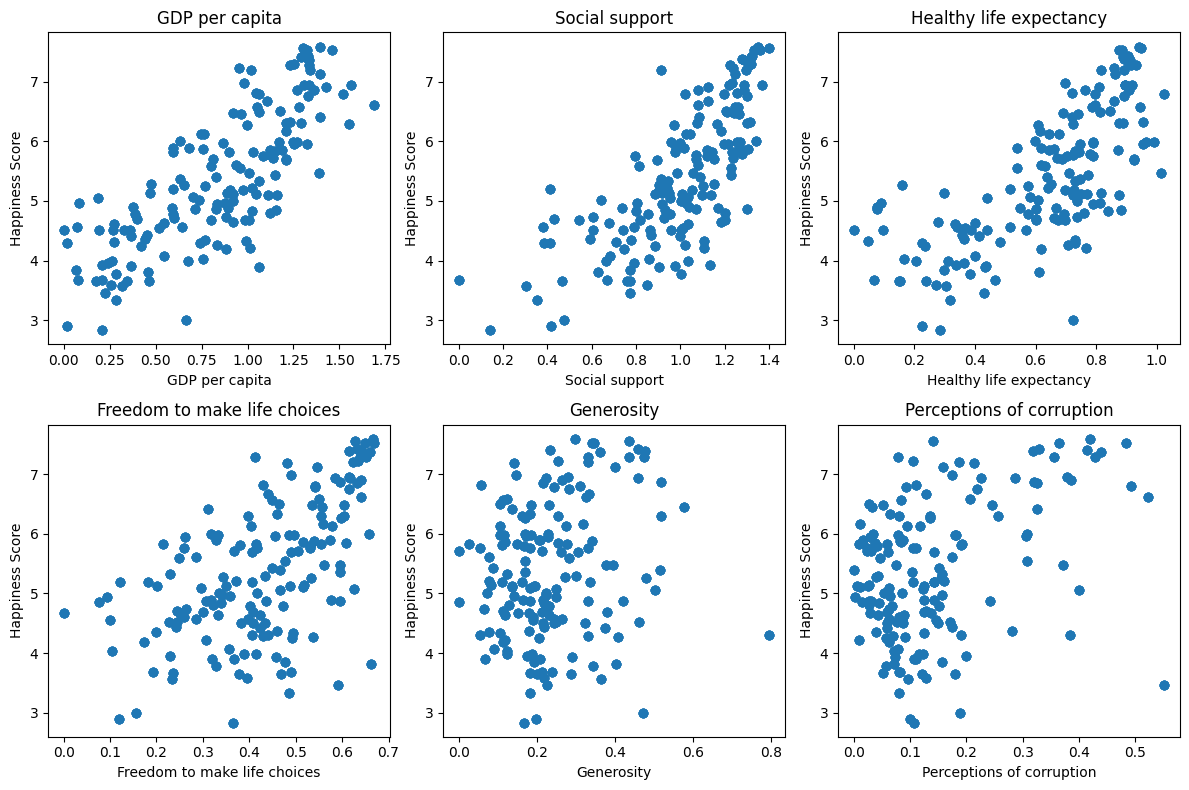

In [4]:
# Scatter plots
features = [
    "GDP per capita",
    "Social support",
    "Healthy life expectancy",
    "Freedom to make life choices",
    "Generosity",
    "Perceptions of corruption"
]

plt.figure(figsize=(12, 8))

for i, feature in enumerate(features, 1):
    plt.subplot(2, 3, i)
    plt.scatter(df[feature], df["Score"])
    plt.xlabel(feature)
    plt.ylabel("Happiness Score")
    plt.title(feature)

plt.tight_layout()
plt.show()

From the scatter plots, several patterns can be observed between the features and the happiness score:

- **GDP per capita,Social support and Healthy life expectancy** show strong positive relationships with happiness

- **Freedom to make life choices** shows a moderate positive relationship

- **Generosity and Perceptions of corruption** shows a weak or slightly negative relationship

Overall, economic and social factors are more important predictors of happiness.

## 1.3 Correlation Analysis of Features
This heatmap visualizes the correlation between different features and the happiness score, helping identify the most important predictors.

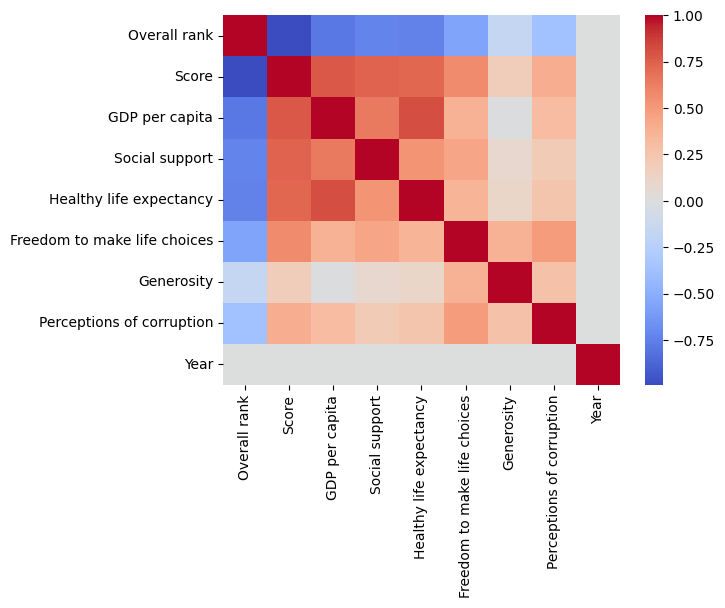

In [5]:
df_numeric = df.select_dtypes(include=['float64', 'int64'])

sns.heatmap(df_numeric.corr(), cmap='coolwarm')
plt.show()

- GDP, social support, and health have the strongest positive correlations with happiness.
- Freedom has a moderate impact.
- Generosity and corruption show weak relationships.

# 2. Model Fitting/Training
The dataset was prepared by selecting relevant features and defining the target variable (happiness score). Two feature sets were considered:

- A reduced set including GDP per capita, social support, and healthy life expectancy
- A full set including all available features

The data was then split into training and testing sets to evaluate model performance.

Two machine learning models were trained:

- Linear Regression
- Random Forest Regressor

The models were evaluated using the R² score on the test set to compare their predictive performance.

## 2.1 Data Preparation for Modeling
This section prepares the data for machine learning by selecting relevant features, defining the target variable, and splitting the dataset into training and testing sets.

In [6]:
from sklearn.model_selection import train_test_split

# Define feature sets
top_features = [
    "GDP per capita",
    "Social support",
    "Healthy life expectancy"
]

all_features = [
    "GDP per capita",
    "Social support",
    "Healthy life expectancy",
    "Freedom to make life choices",
    "Generosity",
    "Perceptions of corruption"
]

# Define target
y = df["Score"]

# -------- Top Features --------
X_top = df[top_features]

X_top_train, X_top_test, y_train, y_test = train_test_split(
    X_top, y, test_size=0.2, random_state=42
)

# -------- All Features --------
X_all = df[all_features]

X_all_train, X_all_test, _, _ = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

print("Top features shape:", X_top.shape)
print("All features shape:", X_all.shape)

Top features shape: (790, 3)
All features shape: (790, 6)


## 2.2 Linear Regression Model
The Linear Regression model is trained using two different feature sets.

- The model using top features achieved an R² score of X.
- The model using all features achieved an R² score of Y.

In [7]:
from sklearn.linear_model import LinearRegression

# ===== Model with Top Features =====
lr_top = LinearRegression()
lr_top.fit(X_top_train, y_train)

score_top_lr = lr_top.score(X_top_test, y_test)
print("Linear Regression (Top Features) R²:", score_top_lr)


# ===== Model with All Features =====
lr_all = LinearRegression()
lr_all.fit(X_all_train, y_train)

score_all_lr = lr_all.score(X_all_test, y_test)
print("Linear Regression (All Features) R²:", score_all_lr)

Linear Regression (Top Features) R²: 0.7588688284418446
Linear Regression (All Features) R²: 0.7898156711133157


## 2.3 Random Forest Model
The Random Forest model is trained using two different feature sets.

- The model using top features achieved an R² score of X.
- The model using all features achieved an R² score of Y.

In [8]:
from sklearn.ensemble import RandomForestRegressor

# ===== Model with Top Features =====
rf_top = RandomForestRegressor(random_state=42)
rf_top.fit(X_top_train, y_train)

score_top_rf = rf_top.score(X_top_test, y_test)
print("Random Forest (Top Features) R²:", score_top_rf)


# ===== Model with All Features =====
rf_all = RandomForestRegressor(random_state=42)
rf_all.fit(X_all_train, y_train)

score_all_rf = rf_all.score(X_all_test, y_test)
print("Random Forest (All Features) R²:", score_all_rf)

Random Forest (Top Features) R²: 0.9979597680992864
Random Forest (All Features) R²: 0.9974607320408112


The Random Forest model achieved an R² close to 1, indicating excellent performance. However, this may indicate either strong predictive power or potential overfitting.  
To ensure that the model generalizes well, it is important to compare its performance on both training and testing data.

In [9]:
# check model overfitting
print("Train R²:", rf_all.score(X_all_train, y_train))
print("Test R²:", rf_all.score(X_all_test, y_test))

Train R²: 0.999566942321101
Test R²: 0.9974607320408112


The model is not overfitting because the training and testing R² scores are very close.

This indicates that the model generalizes well to unseen data rather than simply memorizing the training data.

## 2.4 Model Comparison

Two models were trained: Linear Regression and Random Forest.

The Random Forest model achieved a higher R² score compared to Linear Regression, indicating better performance on the test data.

This suggests that the relationship between features and happiness is not purely linear. Therefore, Random Forest is used for further analysis, including feature importance.

### Feature Importance

The Random Forest model is used to determine the importance of each feature...

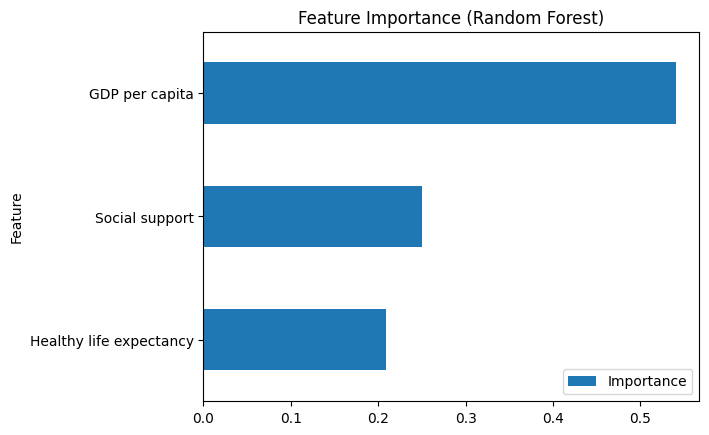

In [10]:
# Choose best model
best_rf = rf_all if score_all_rf > score_top_rf else rf_top
best_X = X_all if score_all_rf > score_top_rf else X_top

importance = pd.DataFrame({
    "Feature": best_X.columns,
    "Importance": best_rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance

#Plot
importance.plot(kind='barh', x='Feature', y='Importance')
plt.title("Feature Importance (Random Forest)")
plt.gca().invert_yaxis()
plt.show()

- GDP per capita is the most important predictor of happiness.
- Social support and health also contribute significantly.
- Economic factors appear to have a stronger impact than non-material factors.

# 3 Conclusions/Implications
GDP per capita, social support, and healthy life expectancy are the most important predictors of happiness.

While non-material factors are significant, they do not have a stronger impact than economic factors, partially rejecting the initial hypothesis.

The Random Forest model performed better than Linear Regression, indicating non-linear relationships between features and happiness.

Overall, both economic and social factors contribute to happiness, with economic conditions playing the dominant role.
